# Import libraries

In [104]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# View data

In [53]:
Path = "../data/dataset-tickets.csv"

In [54]:
df = pd.read_csv(Path)

In [55]:
df.isnull().sum()

subject      3838
body            0
answer          7
type            0
queue           0
priority        0
language        0
version         0
tag_1           0
tag_2          13
tag_3         136
tag_4        3058
tag_5       14042
tag_6       22713
tag_7       26547
tag_8       28022
dtype: int64

In [56]:

df.head(3)

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN


In [57]:
df['type'].value_counts()


type
Incident    11466
Request      8187
Problem      6012
Change       2922
Name: count, dtype: int64

In [58]:
df['queue'].value_counts()


queue
Technical Support                  8362
Product Support                    5252
Customer Service                   4268
IT Support                         3433
Billing and Payments               2788
Returns and Exchanges              1437
Service Outages and Maintenance    1148
Sales and Pre-Sales                 918
Human Resources                     576
General Inquiry                     405
Name: count, dtype: int64

In [59]:
df['priority'].value_counts()


priority
medium    11515
high      11178
low        5894
Name: count, dtype: int64

In [60]:
df['language'].value_counts()


language
en    16338
de    12249
Name: count, dtype: int64

In [61]:
df['version'].value_counts()

version
400    18599
52      9119
51       869
Name: count, dtype: int64

In [62]:
df['body_length'] = df['body'].str.len()
df['answer_length'] = df['answer'].str.len()

In [63]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject        24749 non-null  object 
 1   body           28587 non-null  object 
 2   answer         28580 non-null  object 
 3   type           28587 non-null  object 
 4   queue          28587 non-null  object 
 5   priority       28587 non-null  object 
 6   language       28587 non-null  object 
 7   version        28587 non-null  int64  
 8   tag_1          28587 non-null  object 
 9   tag_2          28574 non-null  object 
 10  tag_3          28451 non-null  object 
 11  tag_4          25529 non-null  object 
 12  tag_5          14545 non-null  object 
 13  tag_6          5874 non-null   object 
 14  tag_7          2040 non-null   object 
 15  tag_8          565 non-null    object 
 16  body_length    28587 non-null  int64  
 17  answer_length  28580 non-null  float64
dtypes: flo

# Exploratory Data Analysis (EDA)

# 1. Distributions of categorical features

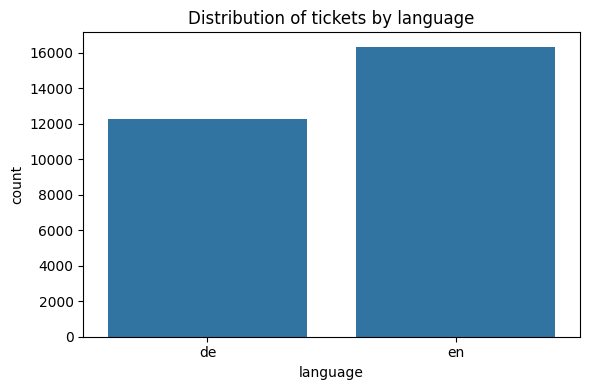

In [76]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="language")
plt.title("Distribution of tickets by language")
plt.tight_layout()
plt.show()


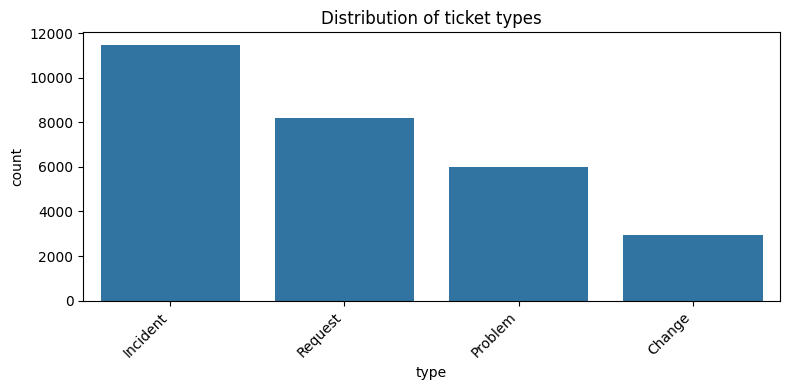

In [77]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="type", order=df["type"].value_counts().index)
plt.title("Distribution of ticket types")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

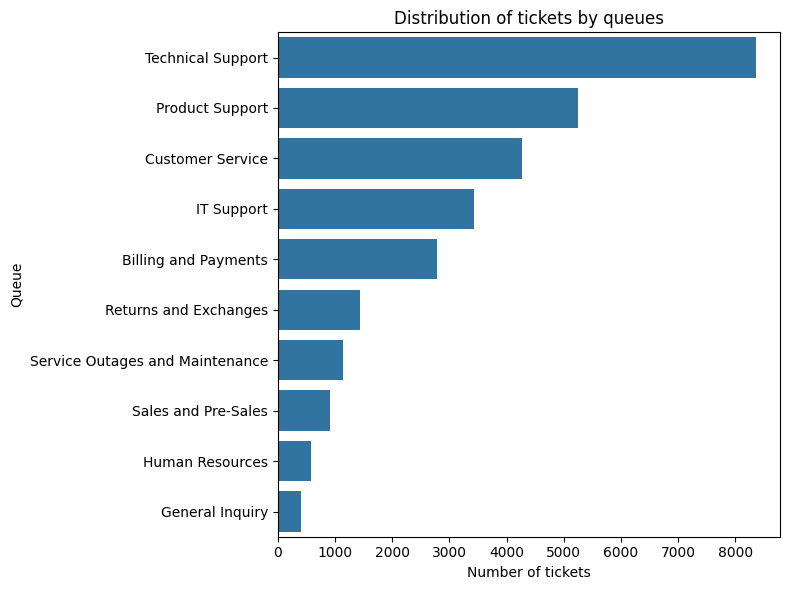

In [78]:
plt.figure(figsize=(8,6))
sns.countplot(y=df["queue"], order=df["queue"].value_counts().index)
plt.title("Distribution of tickets by queues")
plt.xlabel("Number of tickets")
plt.ylabel("Queue")
plt.tight_layout()
plt.show()

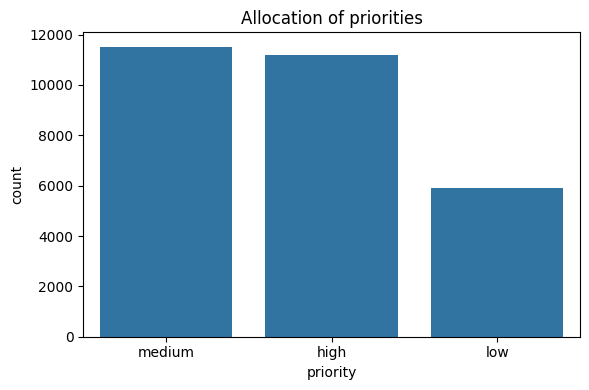

In [79]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="priority", order=df["priority"].value_counts().index)
plt.title("Allocation of priorities")
plt.tight_layout()
plt.show()

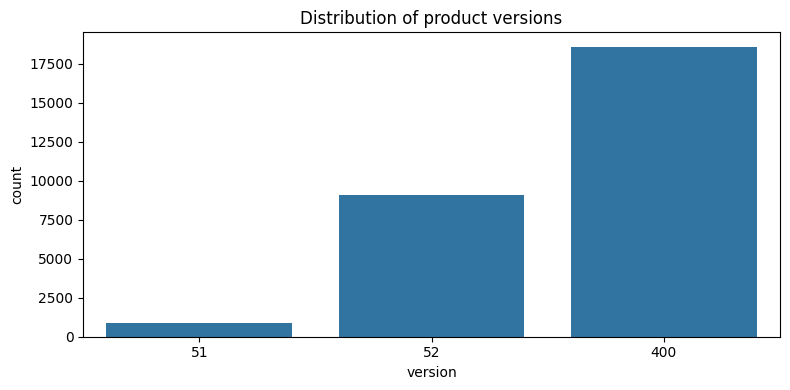

In [80]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="version", order=sorted(df["version"].unique()))
plt.title("Distribution of product versions")
plt.tight_layout()
plt.show()

# 2. Pivot tables

In [81]:
ct_type_queue = pd.crosstab(df["type"], df["queue"])
display(ct_type_queue.head())

queue,Billing and Payments,Customer Service,General Inquiry,Human Resources,IT Support,Product Support,Returns and Exchanges,Sales and Pre-Sales,Service Outages and Maintenance,Technical Support
type,,,,,,,,,,
Change,159,321,120,30,584,601,188,154,273,492
Incident,674,1074,117,316,1244,2306,568,203,630,4334
Problem,615,904,77,57,870,1149,290,119,79,1852
Request,1340,1969,91,173,735,1196,391,442,166,1684


In [82]:

ct_lang_type = pd.crosstab(df["language"], df["type"])
display(ct_lang_type)

type,Change,Incident,Problem,Request
language,,,,
de,1217,4895,2615,3522
en,1705,6571,3397,4665


In [83]:
ct_prio_queue = pd.crosstab(df["priority"], df["queue"])
display(ct_prio_queue)

queue,Billing and Payments,Customer Service,General Inquiry,Human Resources,IT Support,Product Support,Returns and Exchanges,Sales and Pre-Sales,Service Outages and Maintenance,Technical Support
priority,,,,,,,,,,
high,852,805,52,55,1677,1554,307,161,815,4900
low,602,1497,225,286,305,1058,531,332,132,926
medium,1334,1966,128,235,1451,2640,599,425,201,2536


# 3. Heatmap: relationship between types and queues

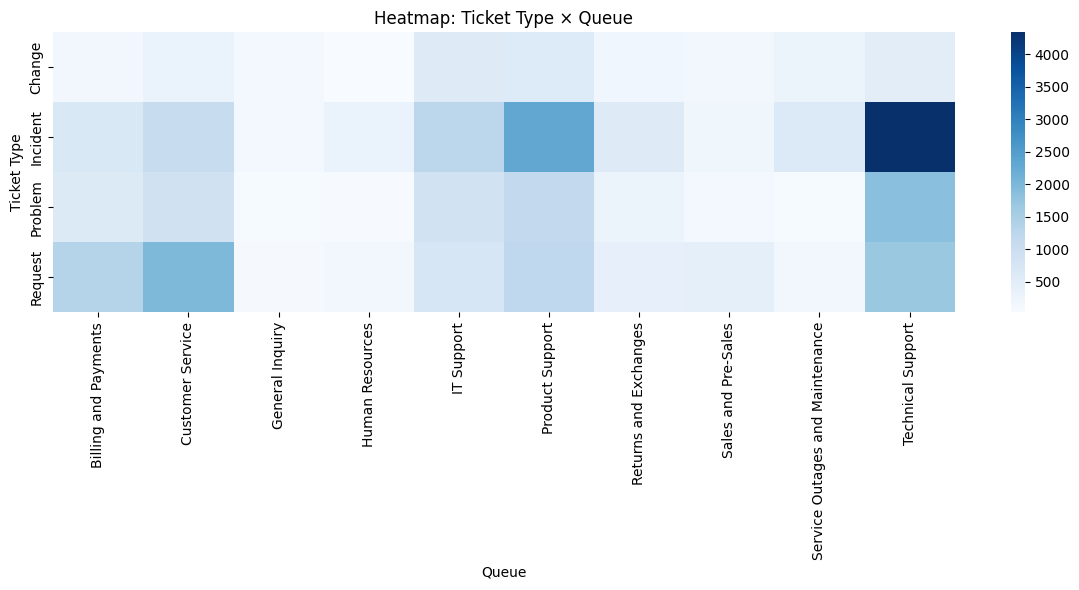

In [84]:
plt.figure(figsize=(12,6))
sns.heatmap(ct_type_queue, cmap="Blues")
plt.title("Heatmap: Ticket Type × Queue")
plt.xlabel("Queue")
plt.ylabel("Ticket Type")
plt.tight_layout()
plt.show()

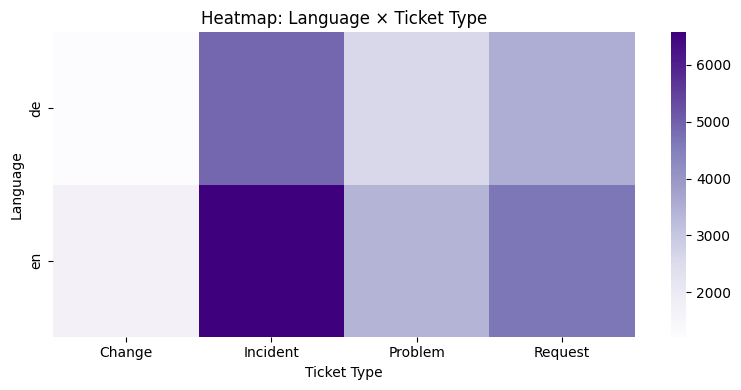

In [85]:
plt.figure(figsize=(8,4))
sns.heatmap(ct_lang_type, cmap="Purples")
plt.title("Heatmap: Language × Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Language")
plt.tight_layout()
plt.show()

# 4. Text length analysis (body_length, answer_length)

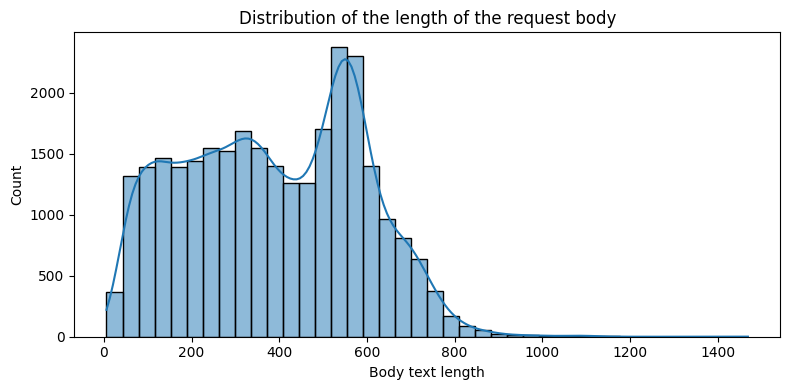

In [86]:
plt.figure(figsize=(8,4))
sns.histplot(df["body_length"], bins=40, kde=True)
plt.title("Distribution of the length of the request body")
plt.xlabel("Body text length")
plt.tight_layout()
plt.show()

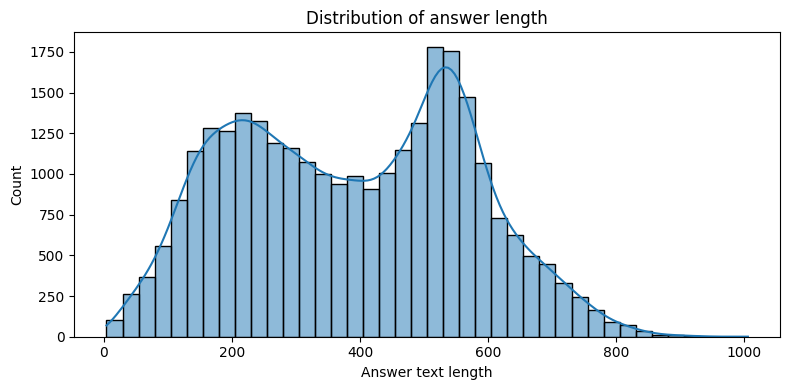

In [87]:

plt.figure(figsize=(8,4))
sns.histplot(df["answer_length"].dropna(), bins=40, kde=True)
plt.title("Distribution of answer length")
plt.xlabel("Answer text length")
plt.tight_layout()
plt.show()


# 5. Comparing text length by category

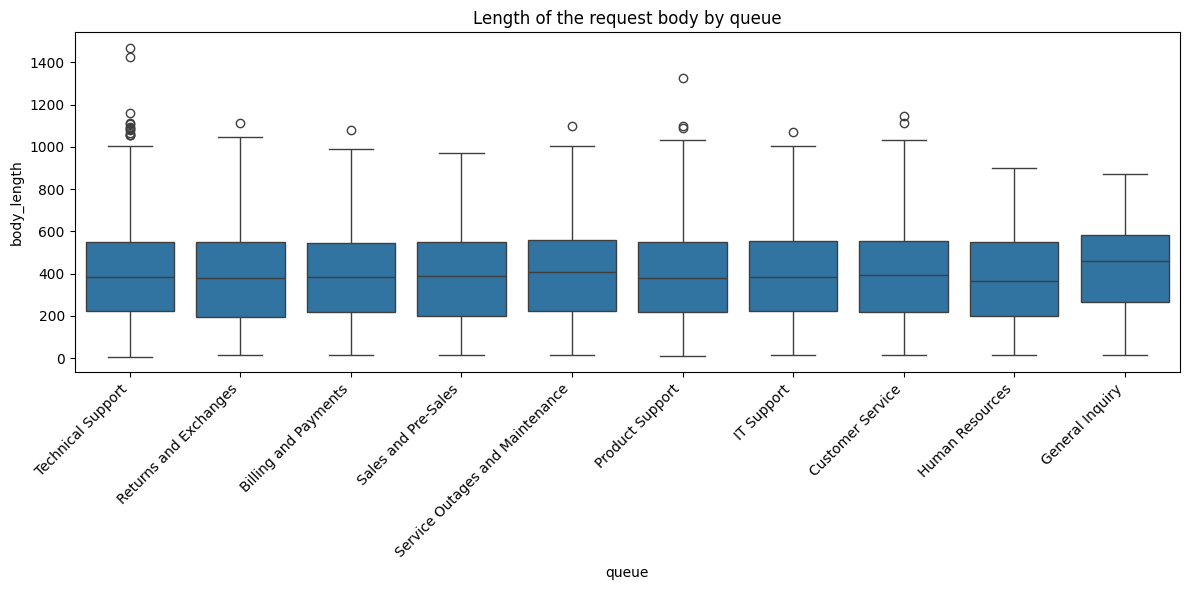

In [88]:

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="queue", y="body_length")
plt.title("Length of the request body by queue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

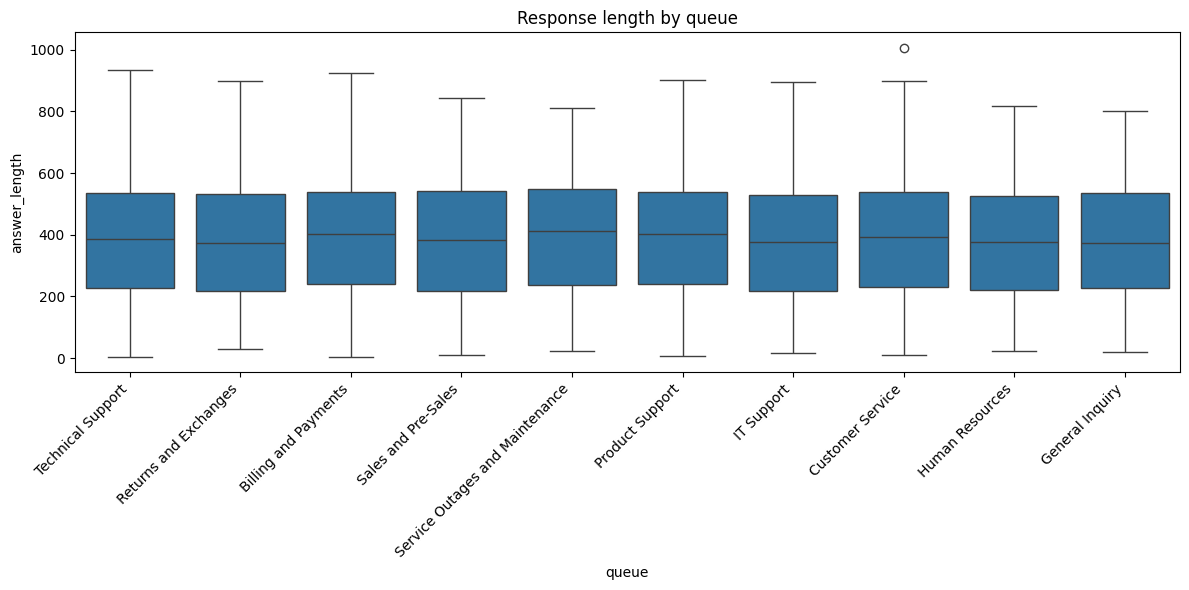

In [89]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="queue", y="answer_length")
plt.title("Response length by queue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

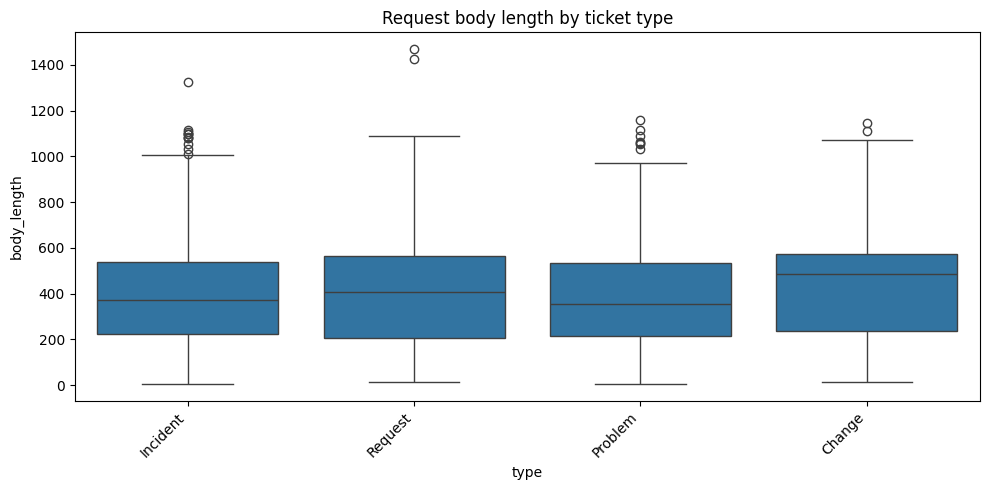

In [90]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="type", y="body_length", order=df["type"].value_counts().index)
plt.title("Request body length by ticket type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

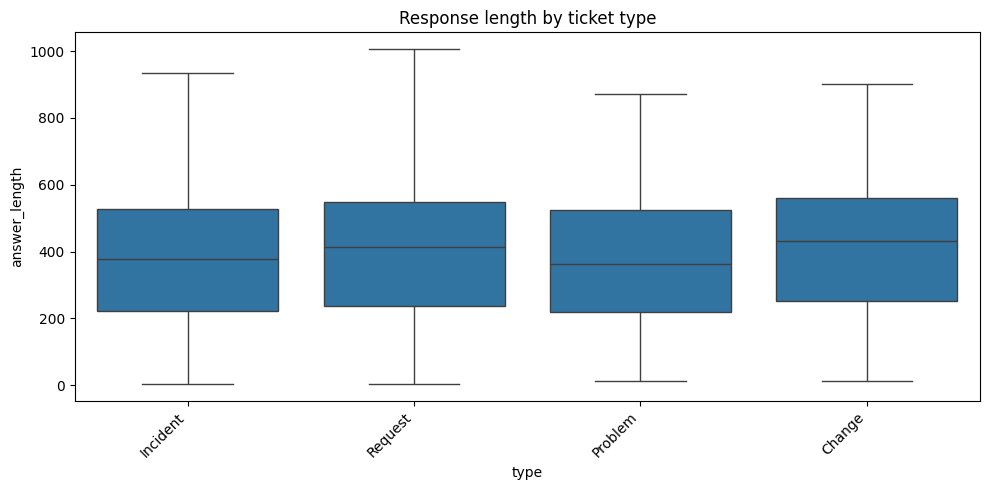

In [91]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="type", y="answer_length", order=df["type"].value_counts().index)
plt.title("Response length by ticket type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


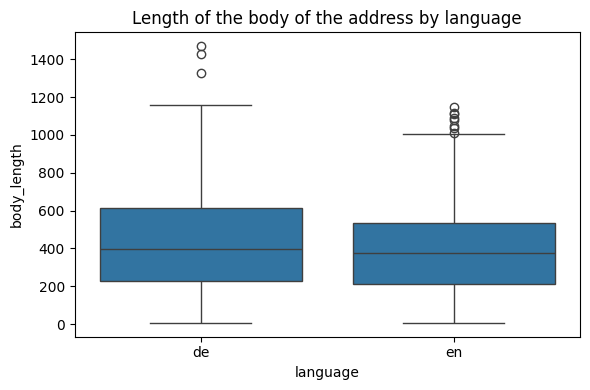

In [92]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="language", y="body_length")
plt.title("Length of the body of the address by language")
plt.tight_layout()
plt.show()

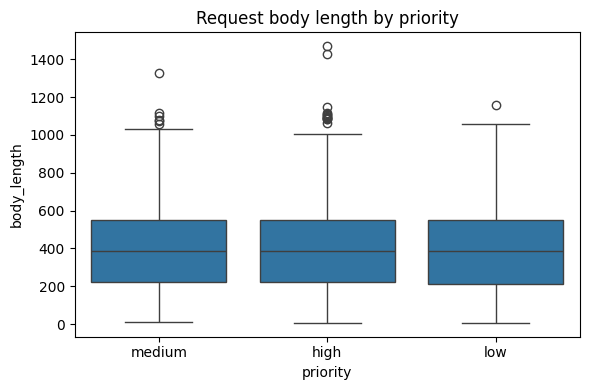

In [93]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="priority", y="body_length",
            order=df["priority"].value_counts().index)
plt.title("Request body length by priority")
plt.tight_layout()
plt.show()

# 6. Relationship between the length of the request and the response

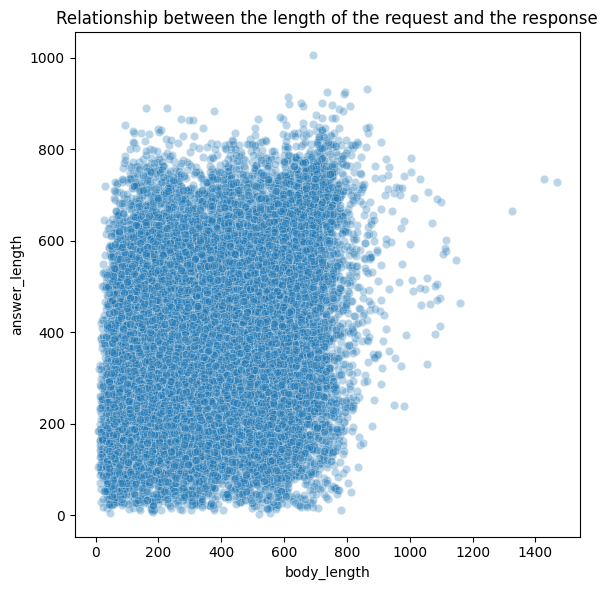

In [94]:
plt.figure(figsize=(6,6))
sns.scatterplot(data=df, x="body_length", y="answer_length", alpha=0.3)
plt.title("Relationship between the length of the request and the response")
plt.xlabel("body_length")
plt.ylabel("answer_length")
plt.tight_layout()
plt.show()


# 7. Tag analysis (tag_1, ..., tag_8)

In [95]:
tag_cols = [f"tag_{i}" for i in range(1, 9)]

In [96]:
tags_df = df[tag_cols].astype(str)

all_tags = (
    tags_df.replace("nan", np.nan)
           .stack()              # превращаем в Series
           .dropna()
           .str.strip()
)
all_tags = all_tags[all_tags != ""]

In [97]:
top_tags = all_tags.value_counts().head(20)
display(top_tags)

Tech Support     16505
IT               16325
Performance      13374
Feedback          7937
Bug               7492
Security          7046
Feature           6660
Documentation     6167
Disruption        5744
Outage            4364
Network           3693
Product           2503
Recovery          2494
Sales             2432
Hardware          1569
Billing           1534
Support           1401
Payment           1269
Marketing         1231
Maintenance       1162
Name: count, dtype: int64

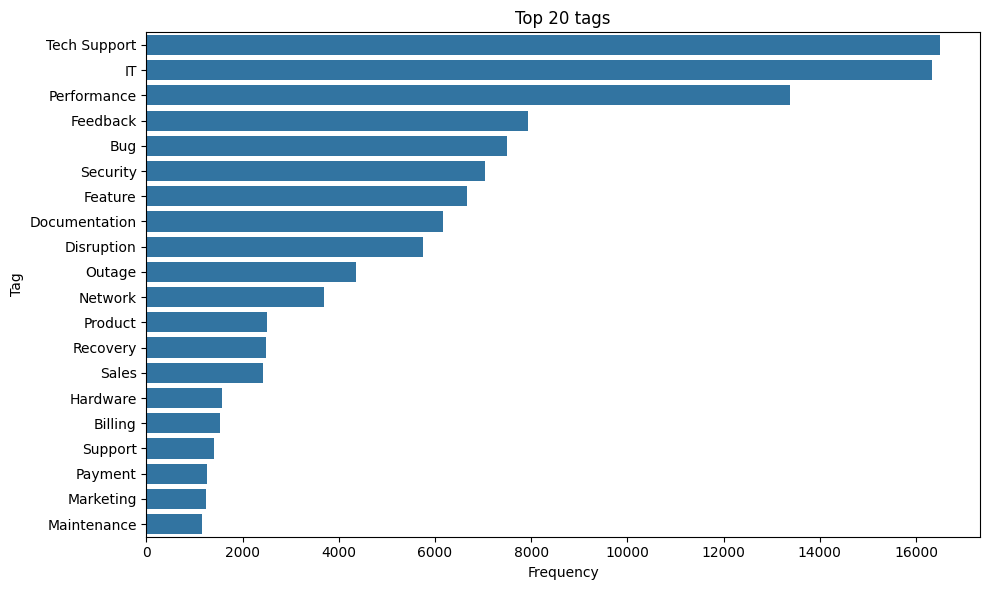

In [98]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_tags.values, y=top_tags.index)
plt.title("Top 20 tags")
plt.xlabel("Frequency")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()

# 8. Average text length by category

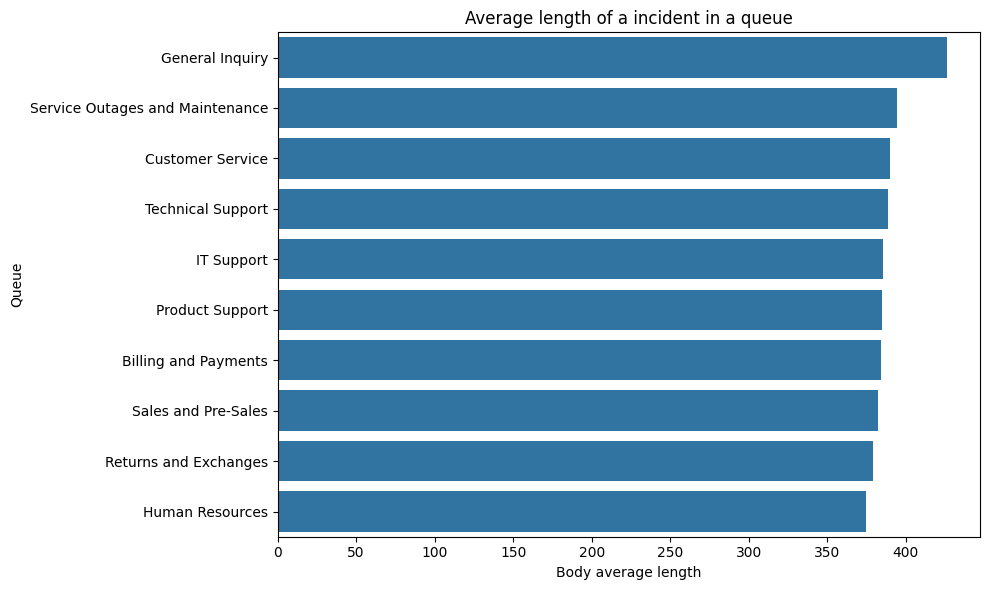

In [99]:
mean_body_by_queue = df.groupby("queue")["body_length"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=mean_body_by_queue.values, y=mean_body_by_queue.index)
plt.title("Average length of a incident in a queue")
plt.xlabel("Body average length")
plt.ylabel("Queue")
plt.tight_layout()
plt.show()

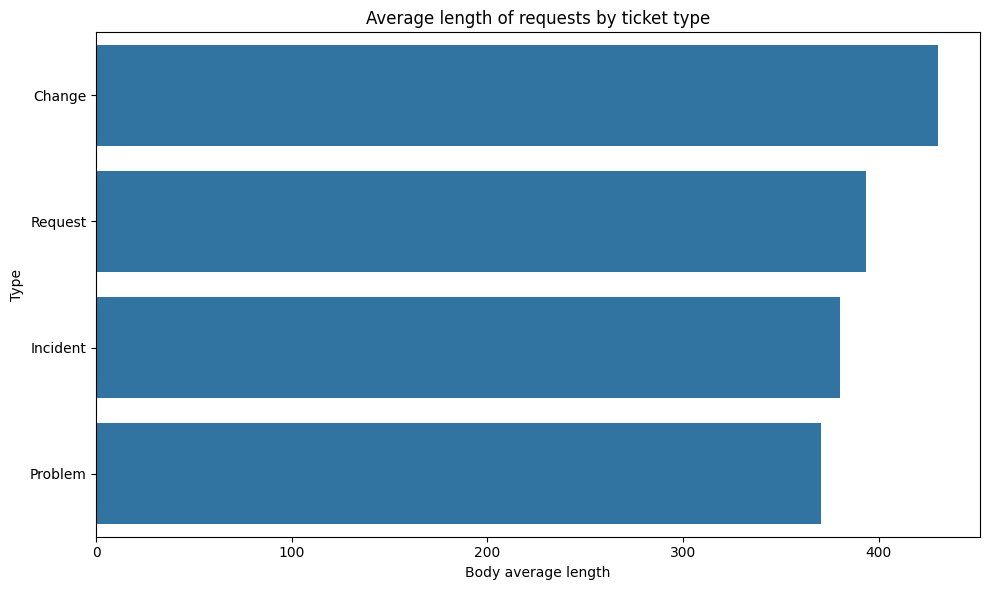

In [100]:
mean_body_by_type = df.groupby("type")["body_length"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=mean_body_by_type.values, y=mean_body_by_type.index)
plt.title("Average length of requests by ticket type")
plt.xlabel("Body average length")
plt.ylabel("Type")
plt.tight_layout()
plt.show()

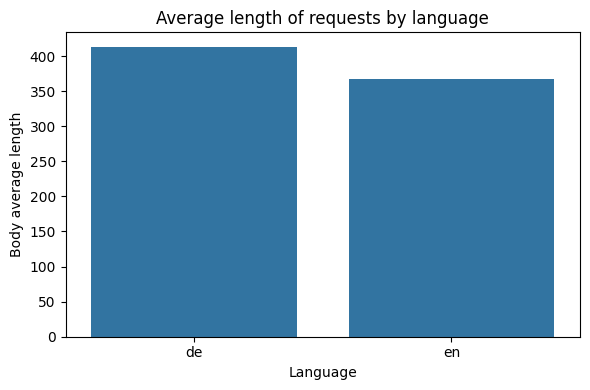

In [102]:

mean_body_by_lang = df.groupby("language")["body_length"].mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=mean_body_by_lang.index, y=mean_body_by_lang.values)
plt.title("Average length of requests by language")
plt.xlabel("Language")
plt.ylabel("Body average length")
plt.tight_layout()
plt.show()


# 9. Wordcloud

In [108]:
queues = df['queue'].unique()

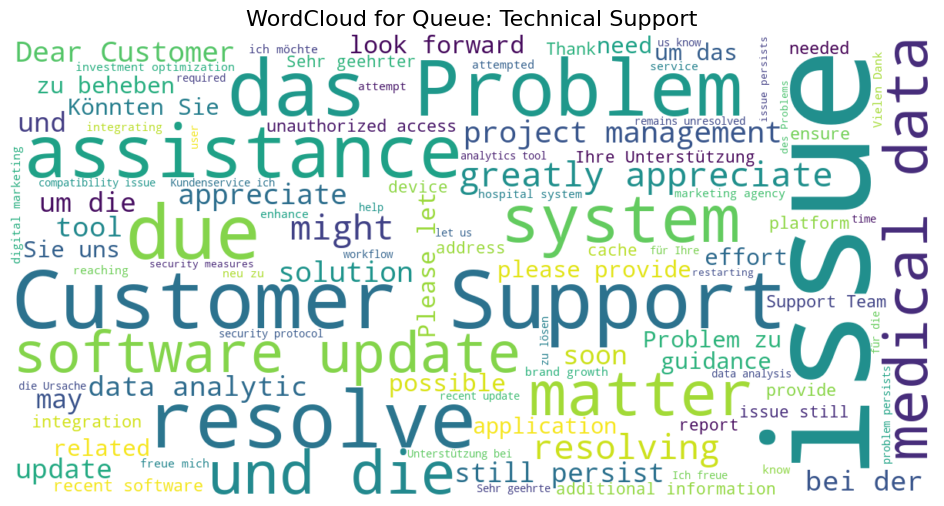

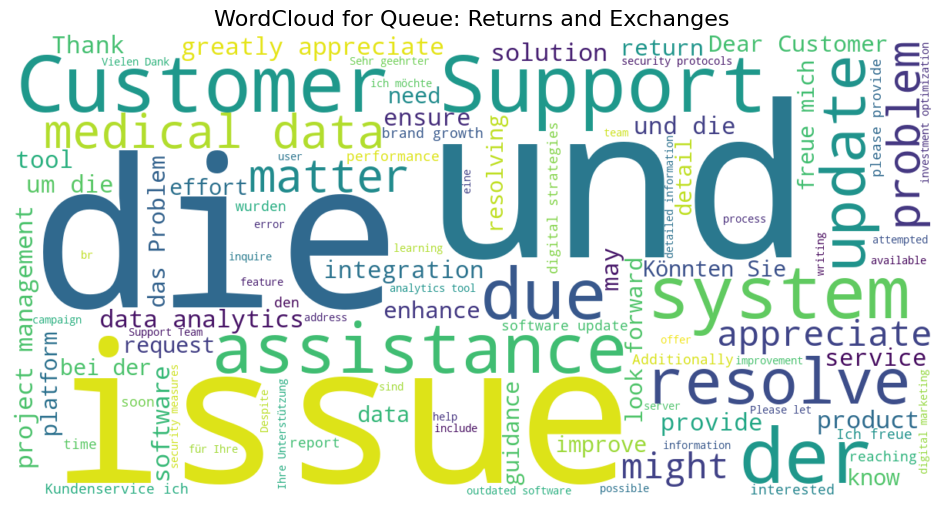

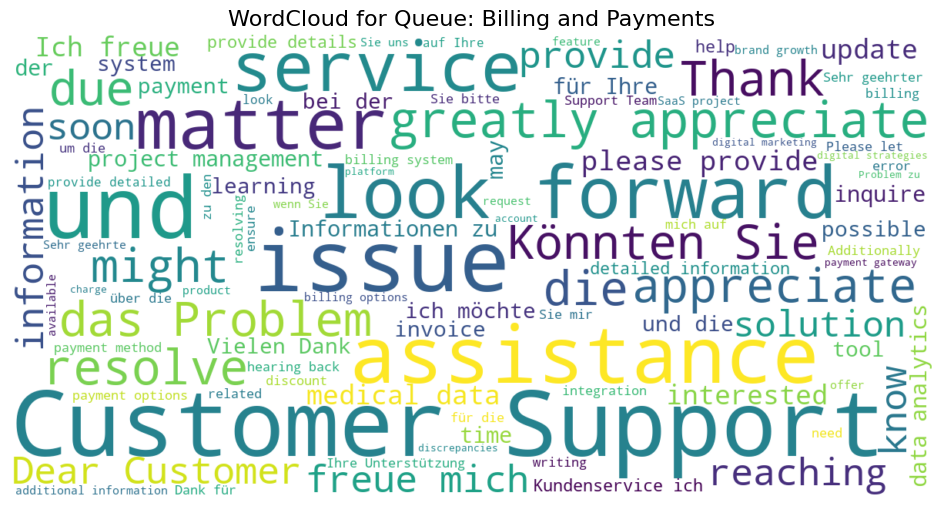

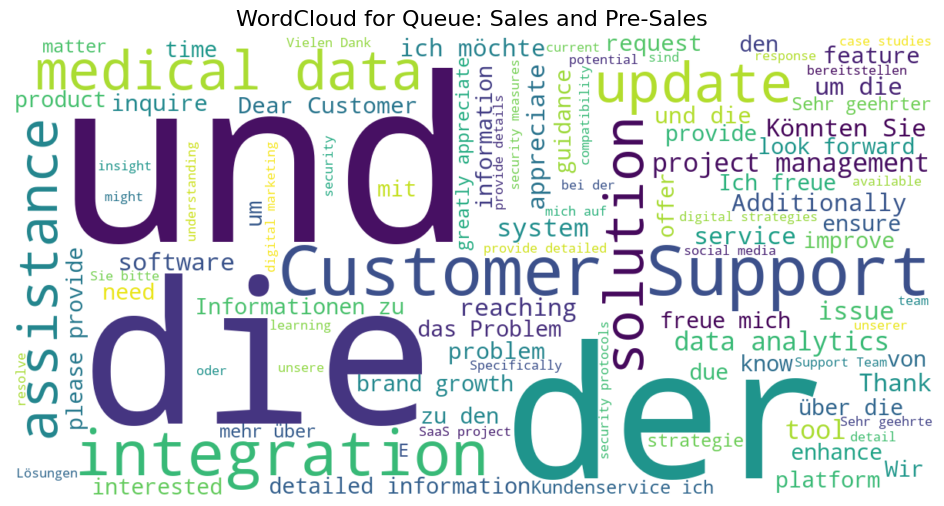

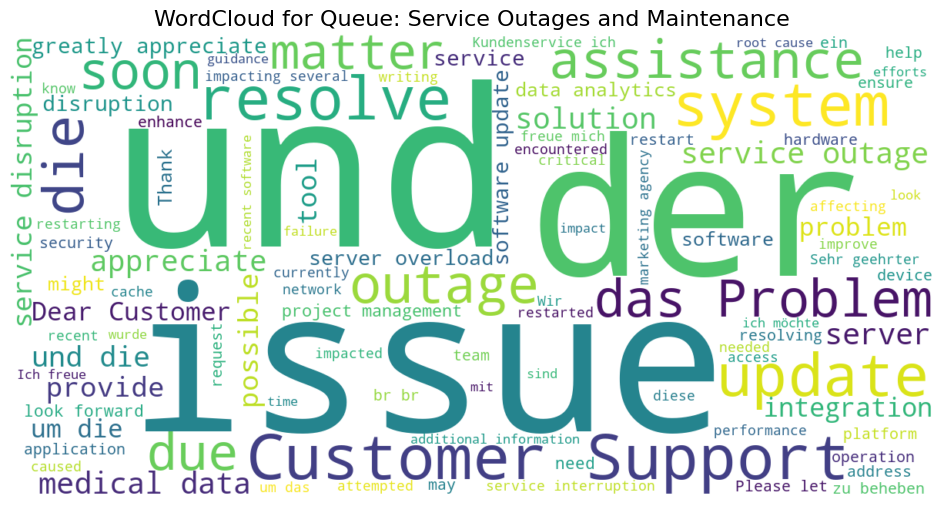

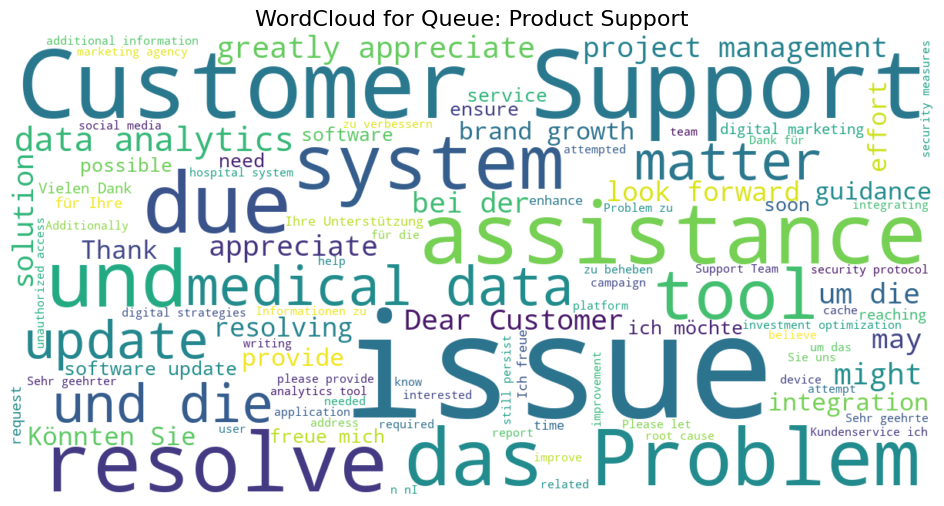

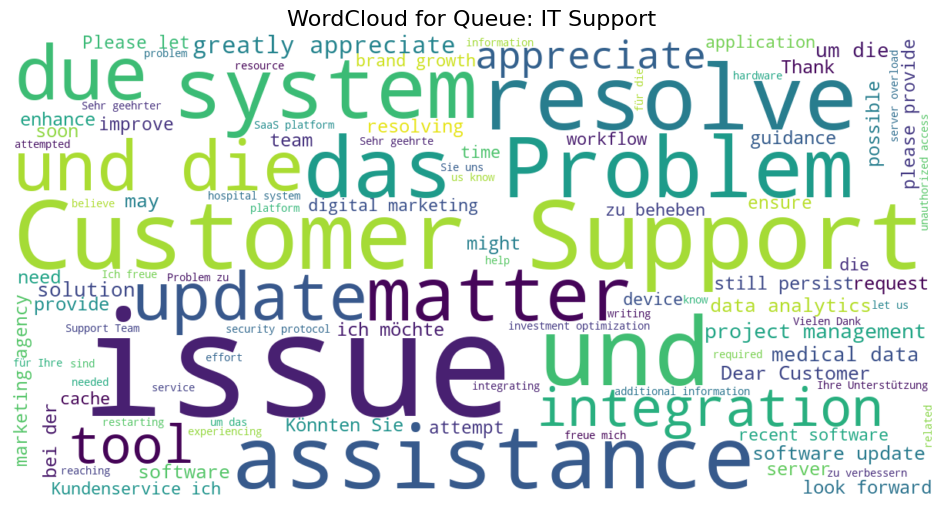

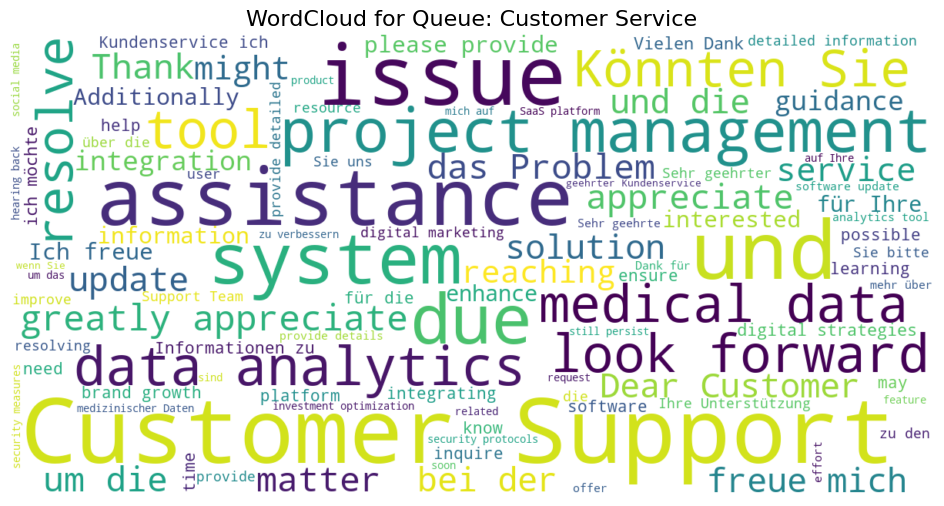

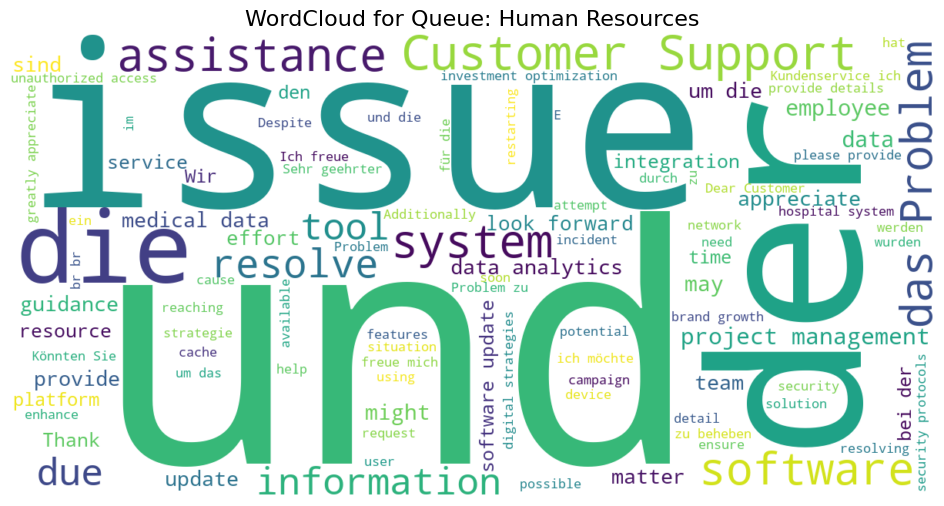

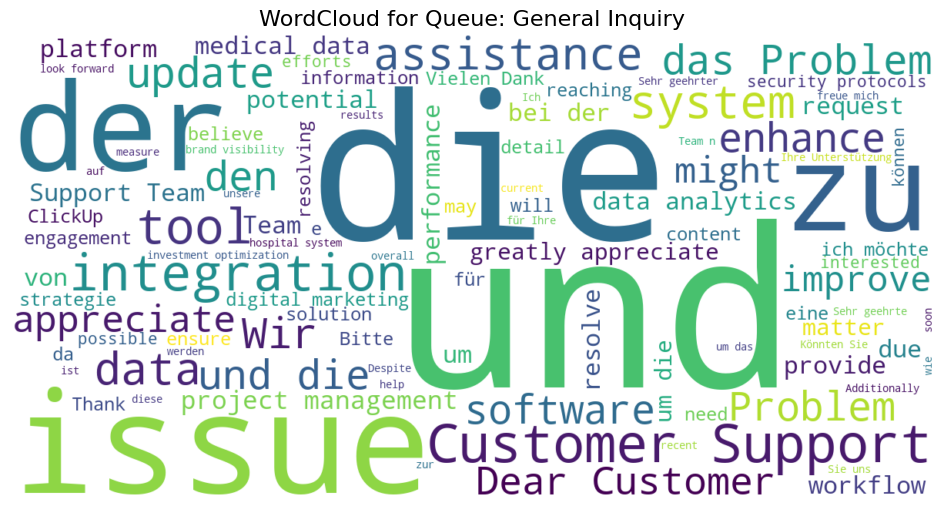

In [109]:
for q in queues:
    subset = df[df['queue'] == q]
    text = " ".join(subset['body'].astype(str).tolist())
    
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        colormap='viridis',
        max_words=100
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud for Queue: {q}", fontsize=16)
    plt.show()